## Figure

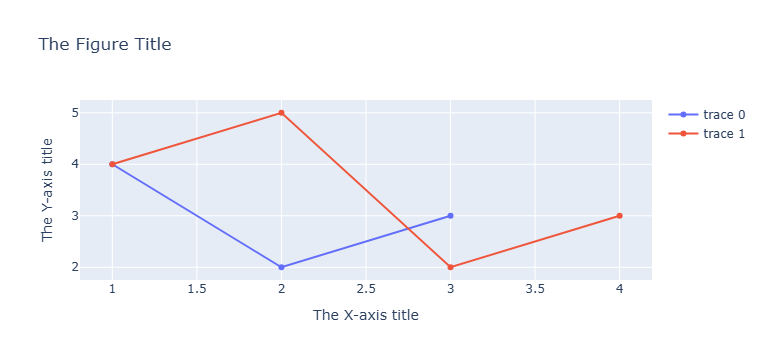

In [1]:
import plotly.graph_objects as go

fig = go.Figure()
fig.add_scatter(x=[1, 2, 3], y=[4, 2, 3])
fig.add_scatter(x=[1, 2, 3, 4], y=[4, 5, 2, 3])

fig.layout.title = 'The Figure Title'
fig.layout.xaxis.title = 'The X-axis title'
fig.layout.yaxis.title = 'The Y-axis title'

fig.show(config={
    'modeBarButtonsToAdd': [
        'drawline',   # Додає кнопку малювання прямої лінії
        'eraseshape'  # Додає кнопку "гумки", щоб можна було видалити намальоване
    ]
})

# fig.write_html('html_plot.html',
#                config={'toImageButtonOptions':
#                        {'format': 'svg'}}
#               )

# fig.write_image('html_plot.svg')



## Population, total

In [3]:
import pandas as pd

poverty_data = pd.read_csv('data/PovStatsData.csv')

regions = ['East Asia & Pacific', 'Europe & Central Asia', 'Fragile and conflict affected situations', 
           'High income', 'IDA countries classified as fragile situations', 'IDA total', 
           'Latin America & Caribbean', 'Low & middle income', 'Low income', 'Lower middle income',
           'Middle East & North Africa', 'Middle income', 'South Asia', 'Sub-Saharan Africa', 
           'Upper middle income', 'World']


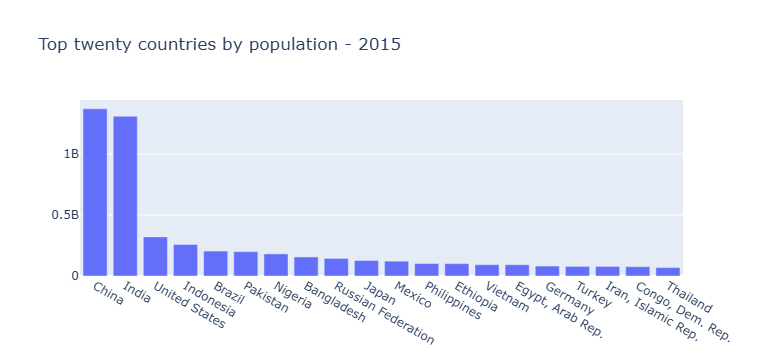

In [9]:
population_df = poverty_data[~poverty_data['Country Name'].isin(regions) &
(poverty_data['Indicator Name']=='Population, total')]

def plot_countries_by_population(year):
    year_df = (population_df[['Country Name', year]]
               .sort_values(year, ascending=False)
            )
    year_df = year_df.iloc[:20, :]
    
    fig = go.Figure()
    fig.add_bar(
        x=year_df['Country Name'], 
        y=year_df[year]
    )
    fig.layout.title = f'Top twenty countries by population - {year}'
    # fig.show()
    return fig

plot_countries_by_population('2015')

## Dropdown -> Graph

In [10]:
from dash import Dash, html, dcc, Input, Output, callback

app = Dash(__name__)

app.layout = html.Div([
    dcc.Dropdown(id='year_dropdown',
                 options=[
                     {'label': year, 'value': str(year)} 
                     for year in range(1974, 2019)
                 ],
                 value='2010' # значення за замоченням
        ),
    dcc.Graph(id='population_chart'),
])

@callback(Output('population_chart', 'figure'),
         Input('year_dropdown', 'value')
         )
# def plot_countries_by_population(year):
#     year_df = (population_df[['Country Name', year]]
#                .sort_values(year, ascending=False)
#             )
#     year_df = year_df.iloc[:20, :]
    
#     fig = go.Figure()
#     fig.add_bar(
#         x=year_df['Country Name'], 
#         y=year_df[year]
#     )
#     fig.layout.title = f'Top twenty countries by population - {year}'
#     return fig
def plot_countres(year):
    fig = plot_countries_by_population(year)
    return fig
    
if __name__ == '__main__':
    app.run(debug=True)